# 1. Import Libraries

In [1]:
import os
import sys
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from datetime import datetime

# 2. File Paths

In [2]:
scripts_path = os.path.abspath(os.path.join('..', 'Scripts'))
if scripts_path not in sys.path:
    sys.path.append(scripts_path)

data_dir = os.path.abspath(os.path.join('..', 'Data', 'TrainTest'))
save_dir = os.path.abspath(os.path.join('..', 'Data', 'SavedModels'))
hyperparameters_dir = os.path.abspath(os.path.join('..', 'Data', 'HyperParameters'))
visualization_dir = os.path.abspath(os.path.join('..', 'Data', 'Visualization'))
results_dir = os.path.abspath(os.path.join('..', 'Data', 'EvaluationResults'))

# 3. Load Models & Data

## 1. Data

### 1. Train Data

In [3]:
# Load data training (70% dari total rating)
# Dipakai sebagai input encoder VAE untuk mengekstrak representasi laten
train_data = np.load(os.path.join(data_dir, "train_data.npy")).astype(np.float32)

num_users, num_items = train_data.shape
print(f"[INFO] Dimensi train data : {num_users} users x {num_items} items")
print(f"[INFO] Jumlah rating      : {int(np.sum(train_data > 0)):,}")

[INFO] Dimensi train data : 943 users x 1682 items
[INFO] Jumlah rating      : 70,000


### 2. Validation Data

In [4]:
# Load data validasi (10% dari total rating)
# Dipakai untuk mencari bobot ensemble optimal (alpha) tanpa melihat test set
MAX_RATING = 5.0

val_data    = np.load(os.path.join(data_dir, "val_data.npy")).astype(np.float32)
val_indices = np.where(val_data > 0)

# Denormalisasi nilai aktual validasi ke skala rating asli (1-5)
actual_val_values = val_data[val_indices] * MAX_RATING

print(f"[INFO] Jumlah rating validasi : {len(actual_val_values):,}")

[INFO] Jumlah rating validasi : 10,000


### 3. Test Data

In [5]:
# Load data test (20% dari total rating)
# Hanya disentuh satu kali untuk pelaporan performa akhir model
test_data    = np.load(os.path.join(data_dir, "test_data.npy")).astype(np.float32)
test_indices = np.where(test_data > 0)

# Denormalisasi nilai aktual test ke skala rating asli (1-5)
actual_test_values = test_data[test_indices] * MAX_RATING

print(f"[INFO] Jumlah rating test     : {len(actual_test_values):,}")

[INFO] Jumlah rating test     : 20,000


## 2. Models

In [6]:
from model import Encoder, Decoder, VAE

# 4. Construct Model

## 1. VAE

In [7]:
# Load hyperparameter terbaik
vae_progress_file = os.path.join(hyperparameters_dir, 'tuning_progress_vae.json')
with open(vae_progress_file, 'r') as f:
    best_vae_params = json.load(f)['best_params']

# Membangun Arsitektur VAE
encoder = Encoder(hidden_dims=best_vae_params['hidden_dims'], latent_dim=best_vae_params['latent_dim'], dropout_rate=best_vae_params['dropout_rate'])
decoder = Decoder(hidden_dims=best_vae_params['hidden_dims'][::-1], output_dim=num_items)
eval_vae = VAE(encoder, decoder, beta=best_vae_params['beta'])

# Menyuntikkan Bobot ke VAE
_ = eval_vae(train_data[:1]) 
eval_vae.load_weights(os.path.join(save_dir, 'trained_best_vae_weights.weights.h5'))

## 2. RSVD

In [8]:
# Memuat komponen Bias
mu = np.load(os.path.join(save_dir, 'final_mu.npy'))
b_u = np.load(os.path.join(save_dir, 'final_b_u.npy'))
b_i = np.load(os.path.join(save_dir, 'final_b_i.npy'))

# Memuat komponen Laten
U = np.load(os.path.join(save_dir, 'best_U.npy'))
Sigma = np.load(os.path.join(save_dir, 'best_Sigma.npy'))
V = np.load(os.path.join(save_dir, 'best_V.npy'))

# 5. Prediction

## 1. VAE

### 1. Extract Latent Space

In [9]:
# Ubah train data menjadi tensor
train_data_tf = tf.constant(train_data, dtype=tf.float32)

# Ekstrak matriks laten
Z_mean, Z_log_var = eval_vae.encoder.predict(train_data_tf, verbose=0)

### 2. Get Prediction

In [10]:
# Prediksi dari Decoder (skala 0 - 1)
pred_vae_norm = eval_vae.decoder.predict(Z_mean, verbose=0)

### 3. Filter Prediction
    FIlter hanya test data saja

In [11]:
pred_vae_test = pred_vae_norm[test_indices]

### 4. Denormalize
    Kembalikan ke skala asli

In [12]:
pred_vae_test_denorm = pred_vae_test * MAX_RATING

### 5. Clip Prediction 
    Batasi prediksi agar tidak keluar dari batas rating

In [13]:
# Batasi prediksi VAE agar tidak keluar dari rentang rating yang valid (1.0 - 5.0)
pred_vae_test_clipped = np.clip(pred_vae_test_denorm, 1.0, MAX_RATING)

## 2. RSVD

### 1. Latent Dot Product

In [14]:
# Kalkulasi matriks laten
latent_matrix = np.dot(np.dot(U, Sigma), V.T)

### 2. Bias Matrix

In [15]:
# Menghitung matriks bias (rata-rata global + bias pengguna + bias film)
bias_matrix = float(mu) + b_u[:, np.newaxis] + b_i[np.newaxis, :]

### 3. Combine

In [16]:
# Gabungkan bias dan interaksi laten menjadi tebakan penuh (Skala 0 - 1)
full_rsvd_pred = bias_matrix + latent_matrix

### 4. Filter Prediction

In [17]:
# Filter untuk indeks test data saja
pred_rsvd_test = full_rsvd_pred[test_indices]

### 5. Denormalize

In [18]:
# Kembalikan prediksi ke skala asli
pred_rsvd_test_denorm = pred_rsvd_test * MAX_RATING

### 6. Clip Prediction

In [19]:
# Batasi prediksi RSVD agar tidak keluar dari rentang rating yang valid (1.0 - 5.0)
pred_rsvd_test_clipped = np.clip(pred_rsvd_test_denorm, 1.0, MAX_RATING)

## 3. Ensemble

### 1. Cari Bobot Ensemble Optimal (Alpha)
    Pencarian alpha dilakukan menggunakan data validasi (bukan test set)
    agar evaluasi akhir di test set tetap tidak bias.

[INFO] Proporsi VAE (Alpha)  : 25%  (0.25)
[INFO] Proporsi RSVD (Beta)  : 75%  (0.75)
[INFO] Val RMSE terbaik      : 0.9380


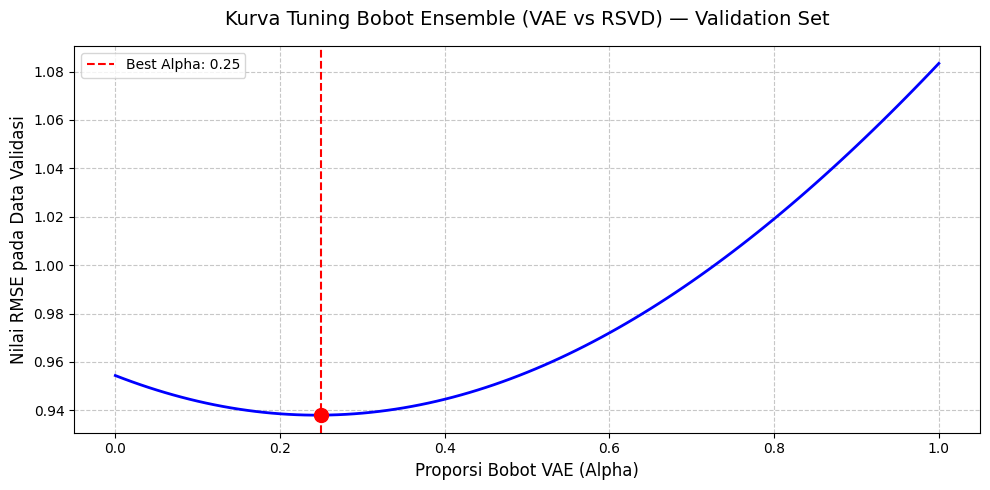

In [20]:
# Ekstrak prediksi VAE dan RSVD di koordinat validasi
# Denormalisasi dan clip ke skala 1-5
pred_vae_val  = np.clip(pred_vae_norm[val_indices]   * MAX_RATING, 1.0, MAX_RATING)
pred_rsvd_val = np.clip(full_rsvd_pred[val_indices]  * MAX_RATING, 1.0, MAX_RATING)

best_val_rmse = float("inf")
best_alpha    = 0.0
best_beta     = 0.0

# Menyimpan history untuk visualisasi kurva tuning
alpha_history = []
rmse_history  = []

# Grid search alpha dari 0.00 hingga 1.00 dengan langkah 0.01
# Alpha = proporsi kontribusi VAE, (1 - alpha) = proporsi kontribusi RSVD
for alpha in np.linspace(0, 1, 101):
    beta          = 1.0 - alpha
    pred_ensemble = np.clip((alpha * pred_vae_val) + (beta * pred_rsvd_val), 1.0, MAX_RATING)
    rmse          = np.sqrt(np.mean(np.square(actual_val_values - pred_ensemble)))

    alpha_history.append(alpha)
    rmse_history.append(rmse)

    if rmse < best_val_rmse:
        best_val_rmse = rmse
        best_alpha    = alpha
        best_beta     = beta

print(f"[INFO] Proporsi VAE (Alpha)  : {best_alpha * 100:.0f}%  ({best_alpha:.2f})")
print(f"[INFO] Proporsi RSVD (Beta)  : {best_beta * 100:.0f}%  ({best_beta:.2f})")
print(f"[INFO] Val RMSE terbaik      : {best_val_rmse:.4f}")

# Visualisasi kurva RMSE vs alpha di data validasi
plt.figure(figsize=(10, 5))
plt.plot(alpha_history, rmse_history, color="blue", linewidth=2)
plt.axvline(x=best_alpha, color="red", linestyle="--", label=f"Best Alpha: {best_alpha:.2f}")
plt.scatter([best_alpha], [best_val_rmse], color="red", s=100, zorder=5)
plt.title("Kurva Tuning Bobot Ensemble (VAE vs RSVD) — Validation Set", fontsize=14, pad=15)
plt.xlabel("Proporsi Bobot VAE (Alpha)", fontsize=12)
plt.ylabel("Nilai RMSE pada Data Validasi", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout()

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
plot_path = os.path.join(visualization_dir, f"ensemble_weight_tuning_{timestamp}.png")
plt.savefig(plot_path, dpi=300)
plt.show()

### 2. Terapkan Alpha ke Test Set

In [21]:
# Terapkan alpha terbaik (yang ditemukan di validasi) ke prediksi test set
pred_vae_test_clipped  = np.clip(pred_vae_norm[test_indices]   * MAX_RATING, 1.0, MAX_RATING)
pred_rsvd_test_clipped = np.clip(full_rsvd_pred[test_indices]  * MAX_RATING, 1.0, MAX_RATING)

pred_hybrid = (best_alpha * pred_vae_test_clipped) + (best_beta * pred_rsvd_test_clipped)

### 3. Clip Prediksi

In [22]:
# Batasi prediksi agar tidak keluar dari rentang rating yang valid (1.0 - 5.0)
pred_hybrid_clipped = np.clip(pred_hybrid, 1.0, MAX_RATING)

# 6. Evaluation

## 1. Helper Function

In [23]:
# Fungsi helper untuk menghitung MSE, RMSE, dan MAE sekaligus
def calculate_metrics(y_true, y_pred):
    """
    Args:
        y_true : np.ndarray nilai rating asli
        y_pred : np.ndarray nilai rating yang diprediksi
    Returns:
        mse, rmse, mae : float
    """
    mse  = np.mean(np.square(y_true - y_pred))
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(y_true - y_pred))
    return mse, rmse, mae

## 2. Calculate Metrics

In [24]:
# Hitung metrik evaluasi untuk ketiga model di test set
mse_v, rmse_v, mae_v = calculate_metrics(actual_test_values, pred_vae_test_clipped)   # VAE
mse_r, rmse_r, mae_r = calculate_metrics(actual_test_values, pred_rsvd_test_clipped)  # RSVD
mse_h, rmse_h, mae_h = calculate_metrics(actual_test_values, pred_hybrid_clipped)     # Hybrid

## 3. Comparison

In [25]:
print(f"=======================================================")
print(f"  HASIL EVALUASI FINAL - TEST SET")
print(f"=======================================================")
print(f"  {'Metrik':<8} | {'VAE':^12} | {'RSVD':^12} | {'Hybrid':^12}")
print(f"  {'-'*8}-+-{'-'*12}-+-{'-'*12}-+-{'-'*12}")
print(f"  {'MSE':<8} | {mse_v:^12.4f} | {mse_r:^12.4f} | {mse_h:^12.4f}")
print(f"  {'RMSE':<8} | {rmse_v:^12.4f} | {rmse_r:^12.4f} | {rmse_h:^12.4f}")
print(f"  {'MAE':<8} | {mae_v:^12.4f} | {mae_r:^12.4f} | {mae_h:^12.4f}")
print(f"=======================================================")
print(f"  Alpha optimal (dari validasi): VAE={best_alpha:.2f}, RSVD={best_beta:.2f}")

  HASIL EVALUASI FINAL - TEST SET
  Metrik   |     VAE      |     RSVD     |    Hybrid   
  ---------+--------------+--------------+-------------
  MSE      |    1.1829    |    0.9037    |    0.8771   
  RMSE     |    1.0876    |    0.9506    |    0.9365   
  MAE      |    0.8446    |    0.7508    |    0.7401   
  Alpha optimal (dari validasi): VAE=0.25, RSVD=0.75


## 4. Save Results

In [26]:
# Simpan seluruh ringkasan metrik agar bisa dipanggil kembali tanpa perlu re-run
evaluation_results = {
    'timestamp': timestamp,
    'ensemble_weights': {
        'best_alpha_vae'  : float(best_alpha),
        'best_beta_rsvd'  : float(best_beta),
        'best_val_rmse'   : float(best_val_rmse)
    },
    'metrics': {
        'vae_standalone'  : {'MSE': float(mse_v), 'RMSE': float(rmse_v), 'MAE': float(mae_v)},
        'rsvd_standalone' : {'MSE': float(mse_r), 'RMSE': float(rmse_r), 'MAE': float(mae_r)},
        'hybrid_ensemble' : {'MSE': float(mse_h), 'RMSE': float(rmse_h), 'MAE': float(mae_h)}
    }
}

evaluation_file_path = os.path.join(results_dir, f'final_testing_results_{timestamp}.json')

with open(evaluation_file_path, 'w') as f:
    json.dump(evaluation_results, f, indent=4)

print(f'[SUCCESS] Hasil evaluasi disimpan ke:')
print(f'          {evaluation_file_path}')

[SUCCESS] Hasil evaluasi disimpan ke:
          c:\Users\Basudewa\Documents\Mata Kuliah\Ujian Proposal\Programs\Data\EvaluationResults\final_testing_results_20260402_2019.json
